In [1]:
import utils
import numpy as np
import pandas as pd
import os
from scipy.stats import chisquare

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme
sns.set_theme()

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)

In [2]:
# Make output folder
output_dir = os.path.join('..','plots','behavioural_pilot','behavioural_modelling')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# Preparation
experiment_output_path = os.path.join('..', '..', 'phd_1_task', 'experiment_output', 'behavioural_files')

In [4]:
unique_subject_ids = [998]
unique_sessions = [0, 1, 2]

recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(experiment_output_path, unique_subject_ids, unique_sessions)
print(recent_results)

['../../phd_1_task/experiment_output/behavioural_files/experiment_output_sub-998_session-00_computer_and_keyboard_2024-06-12_18-02-24.csv', '../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-998_session-01_debug_2024-06-20_09-08-59.csv', '../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-998_session-02_debug_2024-06-19_17-11-46.csv']


In [5]:
# Opens all the files and combines them into one dataframe
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
print(combined_results_dataframe)

      trial  emotional_cue_time response objectively_correct  \
0         0        1.718208e+09     down                Even   
1         1        1.718208e+09     down                Even   
2         2        1.718208e+09     down                Even   
3         3        1.718208e+09       up                Even   
4         4        1.718208e+09       up                Even   
...     ...                 ...      ...                 ...   
2035    675        1.718814e+09     down                True   
2036    676        1.718814e+09       up                True   
2037    677        1.718814e+09     down                True   
2038    678        1.718814e+09     down                True   
2039    679        1.718814e+09       up                True   

     subjectively_correct  response_time   RT_s  stimuli_type  iti  \
0                    True   1.718208e+09  0.965             3    2   
1                    True   1.718208e+09  0.455             1    2   
2                   F

# WSLS
Determine how often the Win-Stay Lost-Shift strategy is used. Plot whether there is a difference between conditions.

In [6]:
# Add congruency as a column
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)

In [7]:
# Add two 'one-back' columns and a WSLS column
dataframe_WSLS = utils.learning_models.add_WSLS_column(combined_results_dataframe)

     subjectively_correct_one_back response_one_back response  WSLS
0                              NaN               NaN     down     0
1166                          Late               NaN     down     0
1155                          Late               NaN     down     0
1130                          Late               NaN       up     0
1098                          Late               NaN     down     0
...                            ...               ...      ...   ...
1627                         False                up       up     4
1628                         False                up       up     4
1629                         False                up       up     4
1621                         False              down     down     4
2039                         False              down     down     4

[2040 rows x 4 columns]


# Check congruency, valence and volatility

In [8]:
# Check a block's congruency
dataframe_WSLS['congruency'] = dataframe_WSLS.apply(utils.analysis_functions.check_congruency, axis=1)

# Check a block's valence
dataframe_WSLS['valence'] = dataframe_WSLS.apply(utils.analysis_functions.check_valence, axis=1)

# Check a block's volatility
dataframe_WSLS = dataframe_WSLS[dataframe_WSLS['probability_condition'] != 50]
dataframe_with_volatility = dataframe_WSLS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)
dataframe_with_volatility = dataframe_with_volatility.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
dataframe_with_volatility.reset_index(drop=True, inplace=True)
print(dataframe_with_volatility[['subject_id', 'session', 'congruency', 'valence', 'volatility', 'WSLS']])

unique_valence_conditions = dataframe_with_volatility['valence'].unique()
unique_congruency_conditions = dataframe_with_volatility['congruency'].unique()
unique_volatility_conditions = dataframe_with_volatility['volatility'].unique()

dataframe_without_volatility = dataframe_WSLS

     subject_id     session   congruency valence volatility  WSLS
0       sub-998  session-00    congruent   angry     stable     1
1       sub-998  session-00    congruent   angry     stable     4
2       sub-998  session-00    congruent   angry     stable     3
3       sub-998  session-00    congruent   angry     stable     2
4       sub-998  session-00    congruent   angry     stable     2
...         ...         ...          ...     ...        ...   ...
2008    sub-998  session-02  incongruent   happy   volatile     3
2009    sub-998  session-02  incongruent   happy   volatile     1
2010    sub-998  session-02  incongruent   happy   volatile     3
2011    sub-998  session-02  incongruent   happy   volatile     4
2012    sub-998  session-02  incongruent   happy   volatile     4

[2013 rows x 6 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5011/1825596363.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataframe_with_volatility = dataframe_WSLS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)


# Plot the WSLS separately for staying and shifting
- Valence
- Volatility
- Congruency
- Valence/Volatility
- Congruency/Volatility

In [9]:
# First combine two columns
grouping_factor = 'valence'
dataframe_valence_volatility = dataframe_with_volatility

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

  subject_id     session valence  p_win_stay  p_lose_stay
0    sub-998  session-00   angry    0.672619     0.524691
1    sub-998  session-00   happy    0.687861     0.467949
2    sub-998  session-01   angry    0.740741     0.503597
3    sub-998  session-01   happy    0.640244     0.496454
4    sub-998  session-02   angry    0.427673     0.552941
5    sub-998  session-02   happy    0.596685     0.516556


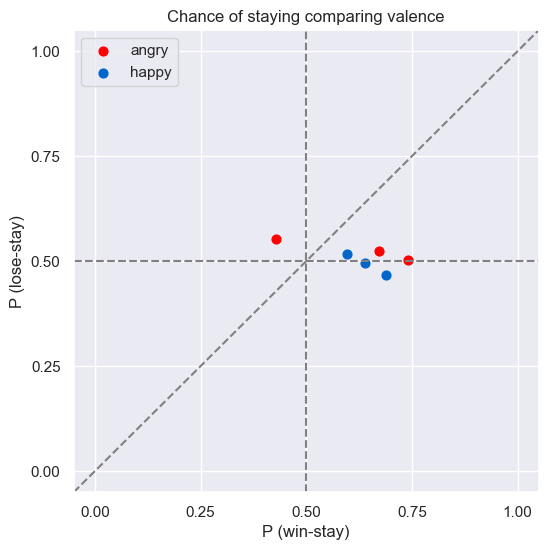

In [10]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(6, 6))
scatterplot_colours = ['#FF0000', '#0066CC']

for index, value in enumerate(unique_valence_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)


# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

In [11]:
# First combine two columns
grouping_factor = 'volatility'
dataframe_valence_volatility = dataframe_with_volatility

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

  subject_id     session volatility  p_win_stay  p_lose_stay
0    sub-998  session-00     stable    0.655844     0.476190
1    sub-998  session-00   volatile    0.700535     0.514620
2    sub-998  session-01     stable    0.745763     0.525424
3    sub-998  session-01   volatile    0.668085     0.481481
4    sub-998  session-02     stable    0.436090     0.483607
5    sub-998  session-02   volatile    0.570048     0.567839


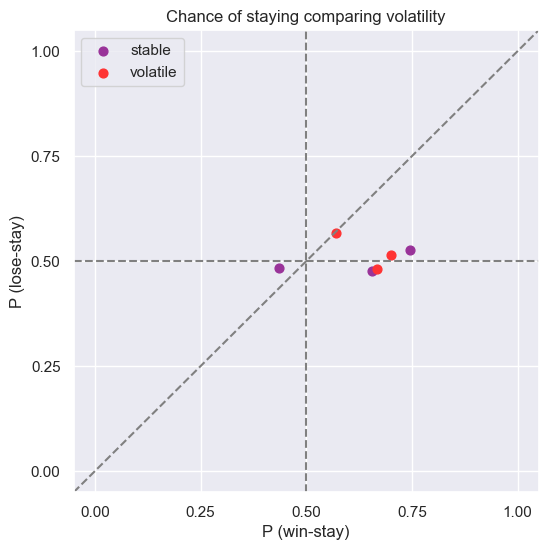

In [12]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(6, 6))
scatterplot_colours = ['#993399', '#FF3333']

for index, value in enumerate(unique_volatility_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)


# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

In [13]:
# First combine two columns
grouping_factor = 'congruency'
dataframe_valence_volatility = dataframe_with_volatility

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

  subject_id     session   congruency  p_win_stay  p_lose_stay
0    sub-998  session-00    congruent    0.670732     0.510989
1    sub-998  session-00  incongruent    0.689266     0.477941
2    sub-998  session-01    congruent    0.720670     0.493590
3    sub-998  session-01  incongruent    0.666667     0.508065
4    sub-998  session-02    congruent    0.494048     0.533784
5    sub-998  session-02  incongruent    0.540698     0.537572


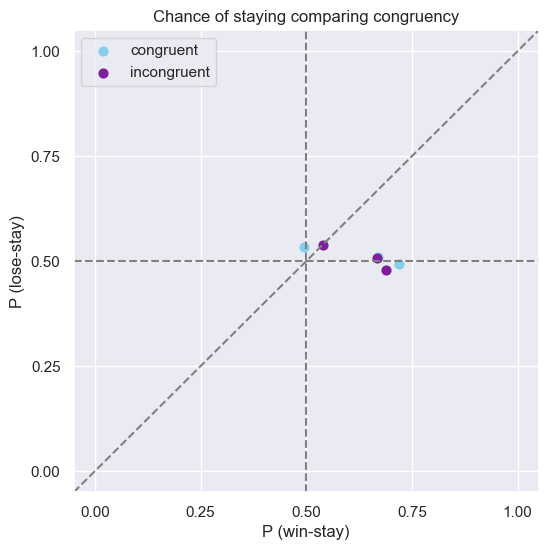

In [14]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(6, 6))
scatterplot_colours = ['#87CEEB', '#7E1E9C']

for index, value in enumerate(unique_congruency_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)


# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

In [15]:
# First combine two columns
grouping_factor_1 = 'valence'
grouping_factor_2 = 'volatility'
grouping_factor = f'{grouping_factor_1}_{grouping_factor_2}'
dataframe_valence_volatility = dataframe_with_volatility
dataframe_valence_volatility[grouping_factor] = dataframe_valence_volatility[grouping_factor_1] + ' & ' + dataframe_valence_volatility[grouping_factor_2]

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session valence_volatility  p_win_stay  p_lose_stay
0     sub-998  session-00     angry & stable    0.690141     0.500000
1     sub-998  session-00   angry & volatile    0.659794     0.548780
2     sub-998  session-00     happy & stable    0.626506     0.447761
3     sub-998  session-00   happy & volatile    0.744444     0.483146
4     sub-998  session-01     angry & stable    0.779661     0.575758
5     sub-998  session-01   angry & volatile    0.723077     0.438356
6     sub-998  session-01     happy & stable    0.711864     0.461538
7     sub-998  session-01   happy & volatile    0.600000     0.516854
8     sub-998  session-02     angry & stable    0.360656     0.567164
9     sub-998  session-02   angry & volatile    0.469388     0.543689
10    sub-998  session-02     happy & stable    0.500000     0.381818
11    sub-998  session-02   happy & volatile    0.660550     0.593750


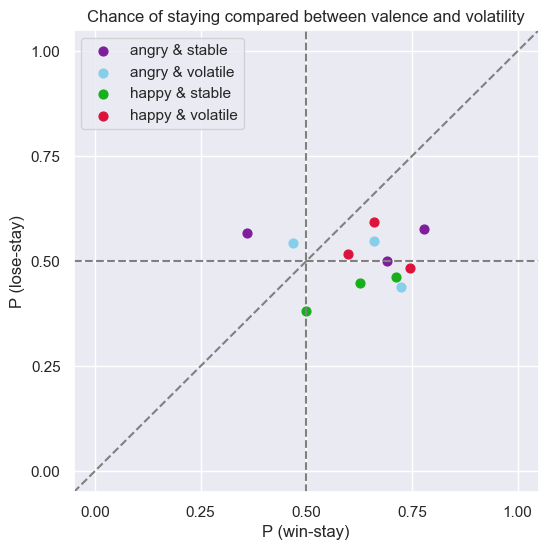

In [16]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(6, 6))
scatterplot_colours = ['#7E1E9C', '#87CEEB', '#15B01A', '#DC143C']
unique_conditions = WSLS_dataframe_averages['valence_volatility'].unique()

for index, value in enumerate(unique_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying compared between {grouping_factor_1} and {grouping_factor_2}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

In [17]:
# First combine two columns
grouping_factor_1 = 'congruency'
grouping_factor_2 = 'volatility'
grouping_factor = f'{grouping_factor_1}_{grouping_factor_2}'
dataframe_valence_volatility = dataframe_with_volatility
dataframe_valence_volatility[grouping_factor] = dataframe_valence_volatility[grouping_factor_1] + ' & ' + dataframe_valence_volatility[grouping_factor_2]

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session   congruency_volatility  p_win_stay  p_lose_stay
0     sub-998  session-00      congruent & stable    0.625000     0.450704
1     sub-998  session-00    congruent & volatile    0.694444     0.549550
2     sub-998  session-00    incongruent & stable    0.673469     0.500000
3     sub-998  session-00  incongruent & volatile    0.708861     0.450000
4     sub-998  session-01      congruent & stable    0.695652     0.533333
5     sub-998  session-01    congruent & volatile    0.724359     0.477477
6     sub-998  session-01    incongruent & stable    0.757895     0.520548
7     sub-998  session-01  incongruent & volatile    0.556962     0.490196
8     sub-998  session-02      congruent & stable    0.450000     0.506173
9     sub-998  session-02    congruent & volatile    0.558824     0.567164
10    sub-998  session-02    incongruent & stable    0.393939     0.439024
11    sub-998  session-02  incongruent & volatile    0.575540     0.568182


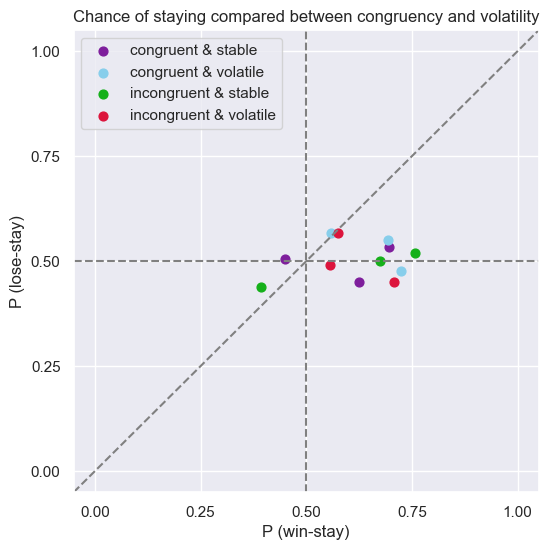

In [18]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(6, 6))
scatterplot_colours = ['#7E1E9C', '#87CEEB', '#15B01A', '#DC143C']
unique_conditions = WSLS_dataframe_averages['congruency_volatility'].unique()

for index, value in enumerate(unique_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying compared between {grouping_factor_1} and {grouping_factor_2}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()